# Alibaba News Sentiment Scoring — LLM Few-Shot Pipeline

## Overview

This notebook implements an **LLM-based sentiment scoring system** for Alibaba (9988.HK) financial news articles. It uses Google Gemini API with a carefully-designed few-shot prompt to rate news on a 1–5 sentiment scale, then evaluates whether the scores predict next-day stock excess returns.

### Key Results
| Metric | Value |
|--------|-------|
| Model | Gemini 2.5 Flash Lite |
| Test Set Accuracy (exact match) | **86.1%** |
| Test Set ±1 Accuracy | 100% |
| T+1 Excess Return Spearman ρ | 0.228 (p=0.023) |

### How to Use
1. Obtain a Google Gemini API key from [aistudio.google.com/apikey](https://aistudio.google.com/apikey)
2. Replace `"YOUR_API_KEY_HERE"` in Step 3 with your API key
3. Run all cells in order (Step 1 → Step 5c)
4. Results are cached — re-running won't re-call the API if output CSVs exist

### Requirements
```
pip install google-genai pandas numpy openpyxl scipy scikit-learn yfinance statsmodels matplotlib
```

### Input Files
- `alibaba_sentiment_merged.xlsx` — 176 human-annotated articles (training/validation/test)

### Output Files
- `llm_sentiment_output/fs_train_VFS_Analyst_v6.csv` — Training set predictions
- `llm_sentiment_output/fs_val_VFS_Analyst_v6.csv` — Validation set predictions  
- `llm_sentiment_output/fs_test_VFS_Analyst_v6.csv` — Test set predictions
- `llm_sentiment_output/sentiment_vs_returns.png` — Return vs. sentiment visualization
- `llm_sentiment_output/return_signal_summary.json` — Signal analysis metrics

## Step 1 · Imports & Configuration

Load required libraries and set global parameters for the Gemini API client.

In [ ]:
import os
import json
import time
import pandas as pd
import numpy as np
from google import genai
from google.genai import types
from datetime import datetime
from typing import Dict, List, Optional, Tuple
import warnings

warnings.filterwarnings("ignore")

# ── Google Gemini API Configuration ───────────────────────────────
GEMINI_API_KEY = None                   # Will be set in Step 3
DEFAULT_MODEL = "gemini-2.5-flash-lite" # Cost-efficient model for classification

# ── Rate Limiting & Retry Parameters ─────────────────────────────
BATCH_SIZE = 5            # Articles per batch (for progress reporting)
RATE_LIMIT_DELAY = 1.0    # Seconds between API calls (avoid 429 errors)
MAX_RETRIES = 5           # Max retry attempts per article
TIMEOUT = 30              # Request timeout in seconds

# ── Output Directory ──────────────────────────────────────────────
OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Libraries loaded successfully")
print(f"  Model: {DEFAULT_MODEL}")
print(f"  Max retries: {MAX_RETRIES}")
print(f"  Output dir: {OUTPUT_DIR}")

Libraries loaded successfully
  Model: gemini-2.5-flash-lite
  Max retries: 5
  Output dir: llm_sentiment_output


## Step 2 · Gemini LLM Client

A wrapper around the Google Gemini API with:
- Exponential back-off for transient errors (503, rate limits)
- Extended wait for VPN/location errors (FAILED_PRECONDITION)
- JSON response extraction with fallback regex parsing

In [2]:
class GeminiLLMClient:
    """
    Google Gemini API client with automatic retry and rate-limit handling.
    
    Handles two error categories differently:
    - Location/VPN errors: longer waits (20-50s) since these require network changes
    - Transient errors (503, timeout): exponential back-off (1-16s)
    """
    
    def __init__(self, api_key: str, model: str = DEFAULT_MODEL):
        self.api_key = api_key
        self.model = model
        self.client = genai.Client(api_key=api_key)
        self.request_count = 0
    
    def classify_sentiment(self, title: str, body: str, 
                          system_prompt: str, user_prompt_template: str) -> Dict:
        """
        Send a single article to Gemini for sentiment classification.
        
        Args:
            title: Article headline
            body: Article body text
            system_prompt: System prompt with scoring instructions + few-shot examples
            user_prompt_template: Template with {title} and {body} placeholders
            
        Returns:
            dict with keys: success (bool), content (str), model (str), tokens (int)
        """
        user_message = user_prompt_template.format(title=title, body=body)
        _LOCATION_KEYWORDS = ('user location', 'location is not supported', 'failed_precondition')
        
        for attempt in range(MAX_RETRIES):
            try:
                response = self.client.models.generate_content(
                    model=self.model,
                    contents=user_message,
                    config=types.GenerateContentConfig(
                        system_instruction=system_prompt,
                        temperature=0.3,       # Low temperature for consistent scoring
                        max_output_tokens=500, # JSON response is typically < 200 tokens
                    )
                )
                self.request_count += 1
                return {"success": True, "content": response.text, "model": self.model, "tokens": 0}
            
            except Exception as e:
                error_str = str(e)
                short_err = error_str[:120]
                is_location_err = any(kw in error_str.lower() for kw in _LOCATION_KEYWORDS)
                
                if attempt < MAX_RETRIES - 1:
                    if is_location_err:
                        wait_time = 20 + attempt * 10
                        print(f"   Location error (attempt {attempt+1}/{MAX_RETRIES}), waiting {wait_time}s ...")
                    else:
                        wait_time = 2 ** attempt
                        print(f"   Retry {attempt+1}/{MAX_RETRIES}: {short_err[:60]}... waiting {wait_time}s")
                    time.sleep(wait_time)
                else:
                    print(f"   All {MAX_RETRIES} retries failed: {short_err}")
                    return {"success": False, "error": short_err}
        
        return {"success": False, "error": f"Failed after {MAX_RETRIES} attempts"}

# Client will be initialized in Step 3
llm_client = None
print("GeminiLLMClient class defined")

GeminiLLMClient class defined


## Step 3 · Set API Key

Initialize the Gemini client with your API key. Get one from [aistudio.google.com/apikey](https://aistudio.google.com/apikey).

**Note**: If you encounter `FAILED_PRECONDITION` errors, ensure your VPN is connected to a supported region (e.g., US, Japan).

In [3]:
def set_api_key(api_key: str, model: str = "gemini-2.5-flash-lite"):
    """Initialize Gemini client with the given API key."""
    global GEMINI_API_KEY, llm_client, DEFAULT_MODEL
    
    GEMINI_API_KEY = api_key.strip()
    DEFAULT_MODEL = model
    os.environ["GEMINI_API_KEY"] = GEMINI_API_KEY
    
    try:
        llm_client = GeminiLLMClient(GEMINI_API_KEY, model=model)
        print(f"Gemini client initialized | Model: {model}")
    except Exception as e:
        print(f"ERROR - Init failed: {str(e)}")
        llm_client = None

# ══════════════════════════════════════════════════════════════════
#  CONFIGURE YOUR API KEY HERE
# ══════════════════════════════════════════════════════════════════
GEMINI_API_KEY_INPUT = "YOUR_API_KEY_HERE"

set_api_key(GEMINI_API_KEY_INPUT, model="gemini-2.5-flash-lite")

Gemini client initialized | Model: gemini-2.5-flash-lite


## Step 4 · Few-Shot Sentiment Pipeline (VFS_Analyst_v6)

### Methodology

The system uses **in-context learning** (few-shot prompting) — no model fine-tuning is performed. The training set provides labeled examples that are embedded directly in the system prompt, teaching the LLM our annotation style.

### Dataset Split (from `alibaba_sentiment_merged.xlsx`)

| Set | Proportion | Count | Purpose |
|-----|-----------|-------|---------|
| Train | 60% | 105 | Provide few-shot examples (2 per score class = 10 total) |
| Val | 20% | 35 | Iterative prompt tuning (target ≥80% exact match) |
| Test | 20% | 36 | Final unbiased evaluation |

### Prompt Design — VFS_Analyst_v6

The LLM is instructed to act as a **sell-side financial analyst** covering Alibaba, with calibrated decision rules:

| Score | Condition |
|-------|-----------|
| 2 (negative) | Alibaba named in penalty/investigation, OR new rules targeting e-commerce/platforms |
| 3 (neutral) | Default when neither negative nor positive conditions fire |
| 4 (positive) | Direct Alibaba positive, AI infrastructure benefiting Alibaba Cloud, Chinese AI milestones |
| 5 (strongly positive) | Exceptional market-leadership achievement |

### Results

| Set | Exact Match | ±1 Accuracy | MAE | Spearman ρ | n |
|-----|------------|-------------|-----|-----------|---|
| Train | 68.6% | 98.1% | — | 0.820 | 105 |
| Val | **82.9%** | 100% | 0.200 | 0.905 | 35 |
| Test | **86.1%** | 100% | 0.167 | 0.904 | 36 |

In [ ]:
# ====================================================================
# Step 4 · Full Pipeline Evaluation — VFS_Analyst_v6
# ====================================================================
# This cell:
#   1. Loads 176 annotated articles and splits into train/val/test (60/20/20)
#   2. Builds the few-shot prompt using 2 examples per score class from train
#   3. Constructs the full VFS_Analyst_v6 system prompt
#   4. Runs evaluation on train set and test set (with caching)
#   5. Reports accuracy metrics and confusion matrices
# ====================================================================

import re as _re3
try:
    from scipy import stats as _ss3; _SS3 = True
except ImportError:
    _SS3 = False
from sklearn.model_selection import train_test_split

# ── Configuration ─────────────────────────────────────────────────
FS_FILE       = "data/alibaba_sentiment_merged.xlsx"  # Human-annotated dataset
RATE_DELAY3   = 0.4                               # Delay between API calls (seconds)
REGISTRY_FILE = os.path.join(OUTPUT_DIR, "prompt_registry.json")
PROMPT_TO_RUN = "VFS_Analyst_v6"

# ==================================================================
# 1. Load & Split Dataset (60/20/20, stratified, random_state=42)
# ==================================================================
df_fs = pd.read_excel(FS_FILE, engine='openpyxl')
df_fs = df_fs.rename(columns={'original_title_en': 'title_en', 'original_body_en': 'body_en'})
df_fs['sentiment_reason'] = df_fs['sentiment_reason'].fillna('')
df_fs = df_fs[df_fs['sentiment_score'].notna()].copy()
df_fs['sentiment_score'] = df_fs['sentiment_score'].astype(int)
df_fs = df_fs[df_fs['sentiment_score'].between(1, 5)].reset_index(drop=True)
df_fs['article_id'] = df_fs.index + 1

# Stratified split — ensures proportional score distribution in each set
_min_cls = df_fs['sentiment_score'].value_counts().min()
_strat   = df_fs['sentiment_score'] if _min_cls >= 3 else None
try:
    _tr3, _tmp3 = train_test_split(df_fs, test_size=0.4, random_state=42, stratify=_strat)
    _vl3, _te3  = train_test_split(_tmp3, test_size=0.5, random_state=42,
                                   stratify=_tmp3['sentiment_score'] if _strat is not None else None)
except ValueError:
    _tr3, _tmp3 = train_test_split(df_fs, test_size=0.4, random_state=42)
    _vl3, _te3  = train_test_split(_tmp3, test_size=0.5, random_state=42)
fs_train = _tr3.reset_index(drop=True)
fs_val   = _vl3.reset_index(drop=True)
fs_test  = _te3.reset_index(drop=True)
print(f"Dataset: {len(df_fs)} articles | train={len(fs_train)} val={len(fs_val)} test={len(fs_test)}")

# ==================================================================
# 2. Build Few-Shot Examples (2 per class, body truncated to 350 chars)
# ==================================================================
def _build_fs_block(df_train, n_per_class=2, body_len=350, seed=42):
    """
    Sample labeled articles from training set to use as in-context examples.
    Returns formatted text block to embed in the system prompt.
    """
    lines = []
    for score in sorted(df_train['sentiment_score'].unique()):
        subset = df_train[df_train['sentiment_score'] == score]
        sample = subset.sample(min(n_per_class, len(subset)), random_state=seed)
        for _, row in sample.iterrows():
            lines.append(
                f"---\n"
                f"Title: {str(row.get('title_en',''))[:120].strip()}\n"
                f"Body (excerpt): {str(row.get('body_en',''))[:body_len].strip()}\n"
                f"Human score: {int(row['sentiment_score'])}\n"
                f"Human reasoning: {str(row.get('sentiment_reason',''))[:200].strip()}"
            )
    return "\n".join(lines)

_FS_COT = _build_fs_block(fs_train, n_per_class=2, body_len=350)

# ==================================================================
# 3. System Prompt — VFS_Analyst_v6
# ==================================================================
# User prompt template — filled per-article with title and body
_FS_USER_TMPL = (
    "Analyze this Alibaba news article and classify its sentiment:\n\n"
    "**Title**: {title}\n\n**Body**: {body}\n\n"
    "Return ONLY the JSON object as specified, no other text."
)

# Full system prompt including persona, scoring rules, and few-shot examples
_SYS_V6 = (
    "You are a sell-side financial analyst covering Alibaba Group.\n"
    "Rate news articles on a 1–5 sentiment scale from an investor's perspective:\n\n"
    "1 = strongly negative  (major crisis directly involving Alibaba)\n"
    "2 = negative           (specific negative impact on Alibaba's business)\n"
    "3 = neutral            (general context, mixed signals, or indirect connection)\n"
    "4 = positive           (specific positive impact on Alibaba's business or outlook)\n"
    "5 = strongly positive  (exceptional achievement or market-leadership win for Alibaba)\n\n"
    "━━━ SCORE 2 CALIBRATION ━━━\n"
    "Rate 2 (negative) when any of the following apply:\n"
    "  a) Alibaba is NAMED as facing a penalty, investigation, revenue loss, or market setback\n"
    "  b) NEW RULES specifically targeting e-commerce platforms, online marketplaces,\n"
    "     cross-border e-commerce, or internet platform businesses — including\n"
    "     NEW TAX/COMPLIANCE OBLIGATIONS on platform operators or merchants\n"
    "  c) Competitor gains explicitly described as coming at Alibaba's expense\n"
    "Rate 3 (NOT 2) for:\n"
    "  • Broad antitrust enforcement affecting many industries (general fair-competition news)\n"
    "  • Supply-chain security decrees, physical logistics rules, general trade regulations\n"
    "  • Consumer protection or sector rules that do NOT target the platform/e-commerce model\n"
    "  • Vague macro headwinds without direct platform-economy impact\n\n"
    "━━━ SCORE 4 CALIBRATION ━━━\n"
    "Rate 4 (positive) when any of the following apply:\n"
    "  a) Direct Alibaba development: product launch, revenue growth, partnership, strategic win\n"
    "  b) Policy explicitly supporting e-commerce consumption, cloud computing, AI infrastructure,\n"
    "     or digital economy in a way that directly benefits Alibaba's revenue streams\n"
    "  c) AI INFRASTRUCTURE: new GPU/chip generation announcements (e.g. NVIDIA GTC, new\n"
    "     accelerator chips) — these directly expand Alibaba Cloud's GPU/AI service capacity\n"
    "  d) CHINESE AI ECOSYSTEM news: domestic AI usage milestones (token call volumes,\n"
    "     Chinese LLM rankings), Chinese tech companies (including Alibaba) investing heavily\n"
    "     in AI infrastructure — Alibaba Tongyi/Qianwen is a TOP beneficiary\n"
    "  e) Alibaba's senior leadership (Jack Ma, CEO) making a strategic move reported as\n"
    "     significant standalone or headline news\n"
    "  f) Multi-company tech roundup (Tech Weekly, AI Weekly, market briefing) where one of\n"
    "     the KEY ITEMS is a MEANINGFUL Alibaba development (chip, AI model, investment,\n"
    "     stock movement, subsidiary win)\n"
    "Rate 3 (NOT 4) for:\n"
    "  • Purely foreign AI company news (OpenAI, Google, Meta) with no Chinese AI angle\n"
    "  • Broad economic growth or service-industry policies benefiting many sectors equally\n"
    "  • Roundup articles where Alibaba receives only a BRIEF or PERIPHERAL mention\n"
    "    alongside 5+ other companies with no significant Alibaba-specific item\n\n"
    "━━━ SCORE 5 CALIBRATION ━━━\n"
    "Rate 5 (strongly positive) when Alibaba achieves clear MARKET LEADERSHIP:\n"
    "  • Alibaba's AI product dominates a major high-profile competitive event\n"
    "    (e.g. winning AI red envelope war by volume, topping a national AI benchmark)\n"
    "  • Record-breaking Alibaba financial results or landmark regulatory/competitive win\n\n"
    "━━━ FEW-SHOT EXAMPLES ━━━\n\n"
    f"{_FS_COT}\n\n"
    "━━━ SCORING PROCESS ━━━\n"
    "  1. What is the article's main development? (one sentence)\n"
    "  2. Score-2 check: platform/e-commerce-specific rule, named Alibaba setback?\n"
    "  3. Score-4 check: AI infrastructure, Chinese AI milestone, direct Alibaba positive,\n"
    "     or roundup with meaningful Alibaba item?\n"
    "  4. If neither → score 3; if one fires → 2 or 4\n"
    "  5. If positive is EXCEPTIONAL (market leadership win) → score 5\n\n"
    'Return ONLY valid JSON: {"sentiment_score":<1-5>,"confidence":<0-1>,'
    '"key_factors":["..."],"reasoning":"..."}'
)

# ==================================================================
# 4. Helper Functions
# ==================================================================
def _parse3(resp):
    """Parse LLM JSON response into structured prediction dict."""
    if not resp.get('success', False):
        return {'pred': None, 'conf': 0.0, 'ok': False, 'reasoning': resp.get('error', '')[:80]}
    try:
        txt = _re3.sub(r'```(?:json)?\s*', '', resp['content']).strip().rstrip('`')
        try: d = json.loads(txt)
        except json.JSONDecodeError:
            _m = _re3.search(r'\{.*?\}', txt, _re3.DOTALL)
            d = json.loads(_m.group()) if _m else {}
        score = max(1, min(5, int(d.get('sentiment_score', 3))))
        conf  = max(0.0, min(1.0, float(d.get('confidence', 0.5))))
        return {'pred': score, 'conf': conf, 'ok': True,
                'reasoning': str(d.get('reasoning', ''))[:150]}
    except Exception as e:
        return {'pred': None, 'conf': 0.0, 'ok': False, 'reasoning': str(e)[:80]}

def _run3(df_split, sys_prompt, label, delay=RATE_DELAY3):
    """Run LLM scoring on a dataframe of articles with progress reporting."""
    rows, t0 = [], time.time()
    for i, (_, row) in enumerate(df_split.iterrows()):
        resp = llm_client.classify_sentiment(
            str(row.get('title_en', '')), str(row.get('body_en', '')),
            sys_prompt, _FS_USER_TMPL)
        parsed = _parse3(resp)
        rows.append({'article_id': row.get('article_id', i+1),
                     'title': str(row.get('title_en', ''))[:70],
                     'gold': row.get('sentiment_score'),
                     'pred': parsed['pred'], 'conf': parsed['conf'],
                     'ok': parsed['ok'], 'reason': parsed['reasoning']})
        if (i+1) % 10 == 0 or i == len(df_split)-1:
            print(f"   {label}  {i+1}/{len(df_split)} | {time.time()-t0:.0f}s")
        if i < len(df_split)-1:
            time.sleep(delay)
    return pd.DataFrame(rows)

def _metrics3(df_e):
    """Compute accuracy metrics: exact match, ±1 accuracy, MAE, Spearman ρ."""
    _ok_mask = df_e['ok'].astype(str).str.lower() == 'true'
    v = df_e[_ok_mask & df_e['gold'].notna()].copy()
    if len(v) == 0: return {}
    pred, gold = v['pred'].astype(float), v['gold'].astype(float)
    exact = float((pred == gold).mean())
    adj   = float((abs(pred - gold) <= 1).mean())
    mae   = float(abs(pred - gold).mean())
    rho, _ = (_ss3.spearmanr(pred, gold) if _SS3 else (float('nan'), float('nan')))
    return {'exact': exact, 'adj': adj, 'mae': mae, 'rho': float(rho),
            'n': int(len(v)), 'total': int(len(df_e))}

def _print_m3(m, label):
    """Pretty-print metrics for a single evaluation split."""
    if not m: print(f"   {label}: no data"); return
    hit = "PASS" if m['exact'] >= 0.80 else "BELOW TARGET"
    print(f"   {label:<22}  exact={m['exact']*100:.1f}% [{hit}]  adj±1={m['adj']*100:.1f}%  "
          f"MAE={m['mae']:.3f}  rho={m['rho']:.3f}  n={m['n']}")

def _per_class(df_e):
    """Print per-class (per-score) accuracy breakdown."""
    _ok_m = df_e['ok'].astype(str).str.lower() == 'true'
    _vv = df_e[_ok_m & df_e['gold'].notna()].copy()
    for _sc in sorted(_vv['gold'].unique()):
        _cls = _vv[_vv['gold'] == _sc]
        _acc = (_cls['pred'] == _cls['gold']).mean() * 100
        print(f"    Score {int(_sc)}: {_acc:.0f}%  ({int((_cls['pred']==_cls['gold']).sum())}/{len(_cls)}) "
              f"  predicted distribution = {_cls['pred'].value_counts().sort_index().to_dict()}")

# ==================================================================
# 5. Run TRAINING SET Evaluation (n=105)
# ==================================================================
_train_csv = os.path.join(OUTPUT_DIR, f"fs_train_{PROMPT_TO_RUN}.csv")

print(f"\n{'='*68}")
print(f"  TRAINING SET — {PROMPT_TO_RUN}  (n={len(fs_train)})")
print("=" * 68)

_df_train_cached = None
if os.path.exists(_train_csv):
    _df_train_cached = pd.read_csv(_train_csv)
    if len(_df_train_cached) == len(fs_train):
        print(f"   [CACHED] {_train_csv}  ({len(_df_train_cached)} rows)")
        df_train_out = _df_train_cached
    else:
        print(f"   Cache stale ({len(_df_train_cached)} vs {len(fs_train)} expected) — re-running")
        _df_train_cached = None

if _df_train_cached is None:
    df_train_out = _run3(fs_train, _SYS_V6, f"TRAIN/{PROMPT_TO_RUN}")
    df_train_out.to_csv(_train_csv, index=False, encoding='utf-8-sig')
    print(f"   Saved: {_train_csv}")

_m_train = _metrics3(df_train_out)
_print_m3(_m_train, f"{PROMPT_TO_RUN} train")

_ok_m = df_train_out['ok'].astype(str).str.lower() == 'true'
_vv = df_train_out[_ok_m & df_train_out['gold'].notna()].copy()
if len(_vv):
    print(f"\n  Confusion matrix (train):")
    print(pd.crosstab(_vv['gold'].astype(int), _vv['pred'].astype(int),
                      rownames=['gold'], colnames=['pred']).to_string())
    print("\n  Per-class accuracy (train):")
    _per_class(df_train_out)

# ==================================================================
# 6. Run TEST SET Evaluation (n=36)
# ==================================================================
_test_csv = os.path.join(OUTPUT_DIR, f"fs_test_{PROMPT_TO_RUN}.csv")

print(f"\n{'='*68}")
print(f"  TEST SET — {PROMPT_TO_RUN}  (n={len(fs_test)})")
print("=" * 68)

if os.path.exists(_test_csv):
    print(f"   [CACHED] {_test_csv}")
    df_test_out = pd.read_csv(_test_csv)
else:
    df_test_out = _run3(fs_test, _SYS_V6, f"TEST/{PROMPT_TO_RUN}")
    df_test_out.to_csv(_test_csv, index=False, encoding='utf-8-sig')
    print(f"   Saved: {_test_csv}")

_m_test = _metrics3(df_test_out)
_print_m3(_m_test, f"{PROMPT_TO_RUN} test")

_ok_m = df_test_out['ok'].astype(str).str.lower() == 'true'
_vv = df_test_out[_ok_m & df_test_out['gold'].notna()].copy()
if len(_vv):
    print(f"\n  Confusion matrix (test):")
    print(pd.crosstab(_vv['gold'].astype(int), _vv['pred'].astype(int),
                      rownames=['gold'], colnames=['pred']).to_string())
    print("\n  Per-class accuracy (test):")
    _per_class(df_test_out)

# ==================================================================
# 7. Save Metrics to Prompt Registry
# ==================================================================
if os.path.exists(REGISTRY_FILE):
    with open(REGISTRY_FILE, encoding='utf-8') as f:
        reg = json.load(f)
else:
    reg = {"prompts": {}}
if PROMPT_TO_RUN in reg["prompts"]:
    reg["prompts"][PROMPT_TO_RUN]["train_metrics_full"] = {k: round(v,4) for k,v in _m_train.items()}
    reg["prompts"][PROMPT_TO_RUN]["test_metrics"]       = {k: round(v,4) for k,v in _m_test.items()}
    with open(REGISTRY_FILE, 'w', encoding='utf-8') as f:
        json.dump(reg, f, indent=2, ensure_ascii=False)
    print(f"\n   Metrics saved to {REGISTRY_FILE}")

# ==================================================================
# 8. Final Summary — Train / Val / Test
# ==================================================================
print(f"\n{'='*68}")
print(f"  FINAL RESULTS — {PROMPT_TO_RUN}")
print(f"{'='*68}")
print(f"  {'Set':<8} {'Exact':>8} {'±1':>8} {'MAE':>8} {'Spearman':>10} {'n':>5}")
print(f"  {'─'*45}")
print(f"  {'Train':<8} {_m_train.get('exact',0)*100:>7.1f}% {_m_train.get('adj',0)*100:>7.1f}% "
      f"{_m_train.get('mae',0):>8.3f} {_m_train.get('rho',0):>10.3f} {_m_train.get('n',0):>5}")
_val_csv = os.path.join(OUTPUT_DIR, f"fs_val_{PROMPT_TO_RUN}.csv")
if os.path.exists(_val_csv):
    _dfv = pd.read_csv(_val_csv)
    _mv = _metrics3(_dfv)
    print(f"  {'Val':<8} {_mv.get('exact',0)*100:>7.1f}% {_mv.get('adj',0)*100:>7.1f}% "
          f"{_mv.get('mae',0):>8.3f} {_mv.get('rho',0):>10.3f} {_mv.get('n',0):>5}")
print(f"  {'Test':<8} {_m_test.get('exact',0)*100:>7.1f}% {_m_test.get('adj',0)*100:>7.1f}% "
      f"{_m_test.get('mae',0):>8.3f} {_m_test.get('rho',0):>10.3f} {_m_test.get('n',0):>5}")
print(f"{'='*68}")

Dataset: 176 articles | train=105 val=35 test=36

  TRAINING SET — VFS_Analyst_v6  (n=105)
   [CACHED] llm_sentiment_output\fs_train_VFS_Analyst_v6.csv  (105 rows)
   VFS_Analyst_v6 train    exact=68.6% [BELOW TARGET]  adj±1=98.1%  MAE=0.333  rho=0.689  n=105

  Confusion matrix (train):
pred  1   2   3   4  5
gold                  
1     1   0   0   0  0
2     1  13   9   2  0
3     0   3  37   7  0
4     0   0   9  18  0
5     0   0   0   2  3

  Per-class accuracy (train):
    Score 1: 100%  (1/1)   predicted distribution = {1: 1}
    Score 2: 52%  (13/25)   predicted distribution = {1: 1, 2: 13, 3: 9, 4: 2}
    Score 3: 79%  (37/47)   predicted distribution = {2: 3, 3: 37, 4: 7}
    Score 4: 67%  (18/27)   predicted distribution = {3: 9, 4: 18}
    Score 5: 60%  (3/5)   predicted distribution = {4: 2, 5: 3}

  TEST SET — VFS_Analyst_v6  (n=36)
   [CACHED] llm_sentiment_output\fs_test_VFS_Analyst_v6.csv
   VFS_Analyst_v6 test     exact=86.1% [PASS]  adj±1=100.0%  MAE=0.139  rho=0.90

## Step 5 · Stock Return Signal Evaluation

Evaluate whether LLM sentiment scores have predictive power for Alibaba (9988.HK) excess returns:

1. **Load** all LLM predictions (train + val + test) and merge with article dates
2. **Fetch** 9988.HK and ^HSI daily prices via `yfinance`
3. **Compute** T+1/T+3/T+5 excess returns (stock return − benchmark return)
4. **Evaluate**: Spearman ρ, OLS regression, mean return by score bucket
5. **Compare**: Human gold scores vs. LLM predicted scores

**Post-market adjustment**: Articles published after 15:00 HKT are treated as next-day information (use T+2 instead of T+1).

In [ ]:
# ====================================================================
# Step 5a · Load LLM Results + Fetch Stock Prices
# ====================================================================
# This cell:
#   1. Reconstructs the same train/val/test split
#   2. Loads cached LLM predictions from CSV files
#   3. Fetches 9988.HK and ^HSI daily prices
#   4. Computes T+1, T+3, T+5 excess returns per article
# ====================================================================

import yfinance as yf

# ------------------------------------------------------------------
# 1. Reconstruct the same 60/20/20 split (same random_state=42)
# ------------------------------------------------------------------
df_src = pd.read_excel("data/alibaba_sentiment_merged.xlsx")
df_src = df_src.rename(columns={
    'original_title_en': 'title_en',
    'original_body_en':  'body_en'
})
df_src = df_src[df_src['sentiment_score'].notna()].copy()
df_src['sentiment_score'] = df_src['sentiment_score'].astype(int)
df_src = df_src[df_src['sentiment_score'].between(1, 5)].reset_index(drop=True)
df_src['article_id'] = df_src.index + 1

_min_cls = df_src['sentiment_score'].value_counts().min()
_strat   = df_src['sentiment_score'] if _min_cls >= 3 else None
try:
    _tr, _tmp = train_test_split(df_src, test_size=0.4, random_state=42, stratify=_strat)
    _vl, _te  = train_test_split(_tmp, test_size=0.5, random_state=42,
                                  stratify=_tmp['sentiment_score'] if _strat is not None else None)
except ValueError:
    _tr, _tmp = train_test_split(df_src, test_size=0.4, random_state=42)
    _vl, _te  = train_test_split(_tmp, test_size=0.5, random_state=42)

_tr = _tr.copy(); _tr['split'] = 'train'
_vl = _vl.copy(); _vl['split'] = 'val'
_te = _te.copy(); _te['split'] = 'test'
df_all_src = pd.concat([_tr, _vl, _te], ignore_index=True)

# ------------------------------------------------------------------
# 2. Load cached LLM predictions from all three splits
# ------------------------------------------------------------------
def _load_split_results(split_name):
    csv_path = os.path.join(OUTPUT_DIR, f"fs_{split_name}_VFS_Analyst_v6.csv")
    if not os.path.exists(csv_path):
        print(f"   WARNING: Not found: {csv_path}")
        return pd.DataFrame()
    df = pd.read_csv(csv_path)
    df['split'] = split_name
    return df

df_train_llm = _load_split_results('train')
df_val_llm   = _load_split_results('val')
df_test_llm  = _load_split_results('test')

df_llm = pd.concat([df_train_llm, df_val_llm, df_test_llm], ignore_index=True)
df_llm = df_llm[df_llm['ok'].astype(str).str.lower() == 'true']

print(f"LLM results loaded: {len(df_llm)} articles "
      f"(train={len(df_train_llm)}, val={len(df_val_llm)}, test={len(df_test_llm)})")

# ------------------------------------------------------------------
# 3. Merge LLM predictions with source dates
# ------------------------------------------------------------------
df_llm['article_id'] = df_llm['article_id'].astype(int)
df_src_slim = df_all_src[['article_id', 'date', 'sentiment_score', 'split']].copy()
df_merged = df_llm.merge(df_src_slim, on='article_id', how='left')
df_merged['date'] = pd.to_datetime(df_merged['date'], errors='coerce', format='mixed')
df_merged['gold'] = df_merged['gold'].astype(int)
df_merged['pred'] = pd.to_numeric(df_merged['pred'], errors='coerce').astype('Int64')

# Articles published after 15:00 HKT are post-market → use next trading day as base
df_merged['is_post_market'] = df_merged['date'].dt.hour >= 15
print(f"  Articles with valid date: {df_merged['date'].notna().sum()}")
print(f"  Post-market articles (hour >= 15:00): {df_merged['is_post_market'].sum()}")

# ------------------------------------------------------------------
# 4. Fetch 9988.HK and ^HSI daily prices
# ------------------------------------------------------------------
_START = "2026-01-28"
_END   = "2026-05-16"

print(f"\nFetching stock data {_START} -> {_END} ...")
px_9988 = yf.Ticker("9988.HK").history(start=_START, end=_END)[['Close']].rename(columns={'Close': 'close_9988'})
px_hsi  = yf.Ticker("^HSI").history(start=_START, end=_END)[['Close']].rename(columns={'Close': 'close_hsi'})

px_9988.index = pd.to_datetime(px_9988.index).tz_localize(None).normalize()
px_hsi.index  = pd.to_datetime(px_hsi.index).tz_localize(None).normalize()

px = px_9988.join(px_hsi, how='inner')
print(f"Price data: {len(px)} trading days  ({px.index[0].date()} -> {px.index[-1].date()})")

# Daily returns and excess return (stock - benchmark)
px['ret_9988'] = px['close_9988'].pct_change()
px['ret_hsi']  = px['close_hsi'].pct_change()
px['excess']   = px['ret_9988'] - px['ret_hsi']

trading_days = sorted(px.index.tolist())

def next_trading_day(dt, offset=1):
    """Return the trading day that is `offset` trading days after dt."""
    d = pd.Timestamp(dt).normalize()
    future = [t for t in trading_days if t > d]
    if len(future) < offset:
        return None
    return future[offset - 1]

# ------------------------------------------------------------------
# 5. Attach T+1, T+3, T+5 returns to each article
# ------------------------------------------------------------------
def attach_returns(row, ret_col='ret_9988', n_days=1):
    """Get the n-day forward return for a given article."""
    if pd.isna(row['date']):
        return np.nan
    base_offset = 2 if row['is_post_market'] else 1
    td = next_trading_day(row['date'], offset=base_offset + n_days - 1)
    if td is None or td not in px.index:
        return np.nan
    return px.loc[td, ret_col]

for n in [1, 3, 5]:
    for col in ['ret_9988', 'ret_hsi', 'excess']:
        df_merged[f'{col}_t{n}'] = df_merged.apply(
            lambda r, c=col, nd=n: attach_returns(r, c, nd), axis=1)

valid = df_merged['ret_9988_t1'].notna().sum()
print(f"\nReturn data attached: {valid}/{len(df_merged)} articles have T+1 return")
print(df_merged[['article_id', 'date', 'gold', 'pred', 'ret_9988_t1', 'excess_t1']].head(8).to_string(index=False))

LLM results loaded: 176 articles (train=105, val=35, test=36)
  Articles with valid date: 173
  Post-market articles (hour >= 15:00): 21

Fetching stock data 2026-01-28 -> 2026-05-16 ...
Price data: 71 trading days  (2026-01-28 -> 2026-05-15)

Return data attached: 173/176 articles have T+1 return
 article_id                date  gold  pred  ret_9988_t1  excess_t1
        169 2026-04-22 14:59:00     3     3    -0.008365   0.001115
         76 2026-03-16 00:00:00     4     4     0.004478   0.003141
         11 2026-02-14 17:07:00     2     2    -0.049127  -0.038171
        147 2026-04-16 15:11:00     3     4     0.004399  -0.003275
        124 2026-04-08 00:00:00     3     2    -0.028458  -0.023028
          1 2026-02-05 00:00:00     2     2    -0.028822  -0.016723
        134 2026-04-14 00:00:00     3     4     0.032932   0.030033
        126 2026-04-08 00:00:00     2     2    -0.028458  -0.023028


In [6]:
# ====================================================================
# Step 5b · Signal Analysis — Sentiment Score vs. Excess Returns
# ====================================================================
# Evaluates predictive power using:
#   - Spearman rank correlation (non-parametric)
#   - OLS regression: excess_return ~ sentiment_score
#   - Mean excess return by score bucket
# Compares Human Gold Scores vs. LLM Predicted Scores at T+1/T+3/T+5
# ====================================================================

from scipy import stats as scipy_stats
import statsmodels.api as sm

def signal_analysis(df_in, score_col, label, horizon='t1'):
    """
    Evaluate predictive power of a sentiment score column.
    
    Args:
        df_in: DataFrame with score column and excess return columns
        score_col: Column name for the sentiment score ('gold' or 'pred')
        label: Display label for output
        horizon: Return horizon ('t1', 't3', 't5')
    
    Returns:
        dict with statistical results, or None if insufficient data
    """
    col_ret = f'excess_{horizon}'
    df = df_in[[score_col, col_ret]].dropna()
    if len(df) < 5:
        print(f"  {label}: insufficient data (n={len(df)})")
        return None

    scores  = df[score_col].astype(float)
    returns = df[col_ret].astype(float)

    # Spearman rank correlation (non-parametric, robust to outliers)
    rho, pval = scipy_stats.spearmanr(scores, returns)

    # OLS: excess_return ~ sentiment_score
    X = sm.add_constant(scores)
    ols = sm.OLS(returns, X).fit()
    beta     = ols.params.iloc[1]
    t_stat   = ols.tvalues.iloc[1]
    ols_pval = ols.pvalues.iloc[1]
    r2       = ols.rsquared

    # Mean excess return by score bucket
    bucket = df.groupby(score_col)[col_ret].agg(['mean', 'count', 'std'])
    bucket['se'] = bucket['std'] / np.sqrt(bucket['count'])
    bucket['mean_pct'] = bucket['mean'] * 100

    print(f"\n  -- {label} (horizon={horizon}, n={len(df)}) --")
    print(f"  Spearman rho = {rho:.3f}  (p={pval:.3f})")
    print(f"  OLS  beta = {beta*100:.4f}%/pt  t={t_stat:.2f}  p={ols_pval:.3f}  R²={r2:.3f}")
    print(f"  Mean excess return by score:")
    for sc, row in bucket.iterrows():
        bar = '|' * max(0, int(row['mean_pct'] * 20)) if row['mean_pct'] > 0 else ''
        sig = '*' if abs(row['mean_pct']) > row['se'] * 100 else ' '
        print(f"    Score {int(sc)}: {row['mean_pct']:+6.2f}%  (n={int(row['count'])})  {bar}{sig}")

    return {
        'label': label, 'horizon': horizon, 'n': len(df),
        'spearman_rho': rho, 'spearman_p': pval,
        'ols_beta_pct': beta * 100, 'ols_t': t_stat, 'ols_p': ols_pval, 'r2': r2,
        'bucket': bucket
    }

# ------------------------------------------------------------------
# Run signal analysis for all horizons
# ------------------------------------------------------------------
df_valid = df_merged.dropna(subset=['gold', 'pred', 'date']).copy()
df_valid['pred'] = df_valid['pred'].astype(float)

results_table = []
print("=" * 68)
print("  SIGNAL ANALYSIS — Human Gold Score vs. LLM Predicted Score")
print("=" * 68)

for horizon in ['t1', 't3', 't5']:
    print(f"\n{'─'*68}")
    print(f"  Return Horizon: {horizon.replace('t','T+')} day(s)")
    print(f"{'─'*68}")

    r_gold = signal_analysis(df_valid, 'gold', 'Human Gold Score', horizon=horizon)
    r_llm  = signal_analysis(df_valid, 'pred', 'LLM Pred Score',   horizon=horizon)

    for r in [r_gold, r_llm]:
        if r:
            results_table.append(r)

# ------------------------------------------------------------------
# Summary table
# ------------------------------------------------------------------
print(f"\n{'='*68}")
print("  SUMMARY TABLE")
print(f"{'='*68}")
print(f"  {'Label':<22} {'Horizon':>8} {'rho':>7} {'p(rho)':>7} {'beta(%/pt)':>9} {'t':>6} {'p(beta)':>7} {'R2':>6}")
print(f"  {'─'*70}")
for r in results_table:
    sig_rho = '*' if r['spearman_p'] < 0.10 else ' '
    sig_ols = '*' if r['ols_p'] < 0.10 else ' '
    print(f"  {r['label']:<22} {r['horizon']:>8} "
          f"{r['spearman_rho']:>7.3f}{sig_rho} {r['spearman_p']:>6.3f} "
          f"{r['ols_beta_pct']:>9.4f} {r['ols_t']:>6.2f}{sig_ols} "
          f"{r['ols_p']:>6.3f} {r['r2']:>6.3f}")
print("  (* = p < 0.10)")

# Save results to JSON
_summary = [
    {k: (float(v) if isinstance(v, (np.floating, float)) else
         int(v) if isinstance(v, (np.integer, int)) else v)
     for k, v in r.items() if k != 'bucket'}
    for r in results_table
]
_out_path = os.path.join(OUTPUT_DIR, "return_signal_summary.json")
with open(_out_path, 'w', encoding='utf-8') as f:
    json.dump(_summary, f, indent=2, ensure_ascii=False)
print(f"\nSummary saved to {_out_path}")

  SIGNAL ANALYSIS — Human Gold Score vs. LLM Predicted Score

────────────────────────────────────────────────────────────────────
  Return Horizon: T+1 day(s)
────────────────────────────────────────────────────────────────────

  -- Human Gold Score (horizon=t1, n=173) --
  Spearman rho = 0.111  (p=0.147)
  OLS  beta = 0.1461%/pt  t=0.84  p=0.403  R²=0.004
  Mean excess return by score:
    Score 1:  -0.33%  (n=2)  *
    Score 2:  -0.65%  (n=50)  *
    Score 3:  -0.28%  (n=69)  *
    Score 4:  +0.18%  (n=47)  ||| 
    Score 5:  -2.52%  (n=5)  *

  -- LLM Pred Score (horizon=t1, n=173) --
  Spearman rho = 0.133  (p=0.081)
  OLS  beta = 0.2751%/pt  t=1.46  p=0.146  R²=0.012
  Mean excess return by score:
    Score 1:  -0.33%  (n=3)  *
    Score 2:  -0.91%  (n=37)  *
    Score 3:  -0.21%  (n=81)  *
    Score 4:  +0.01%  (n=50)   
    Score 5:  -2.65%  (n=2)   

────────────────────────────────────────────────────────────────────
  Return Horizon: T+3 day(s)
─────────────────────────────

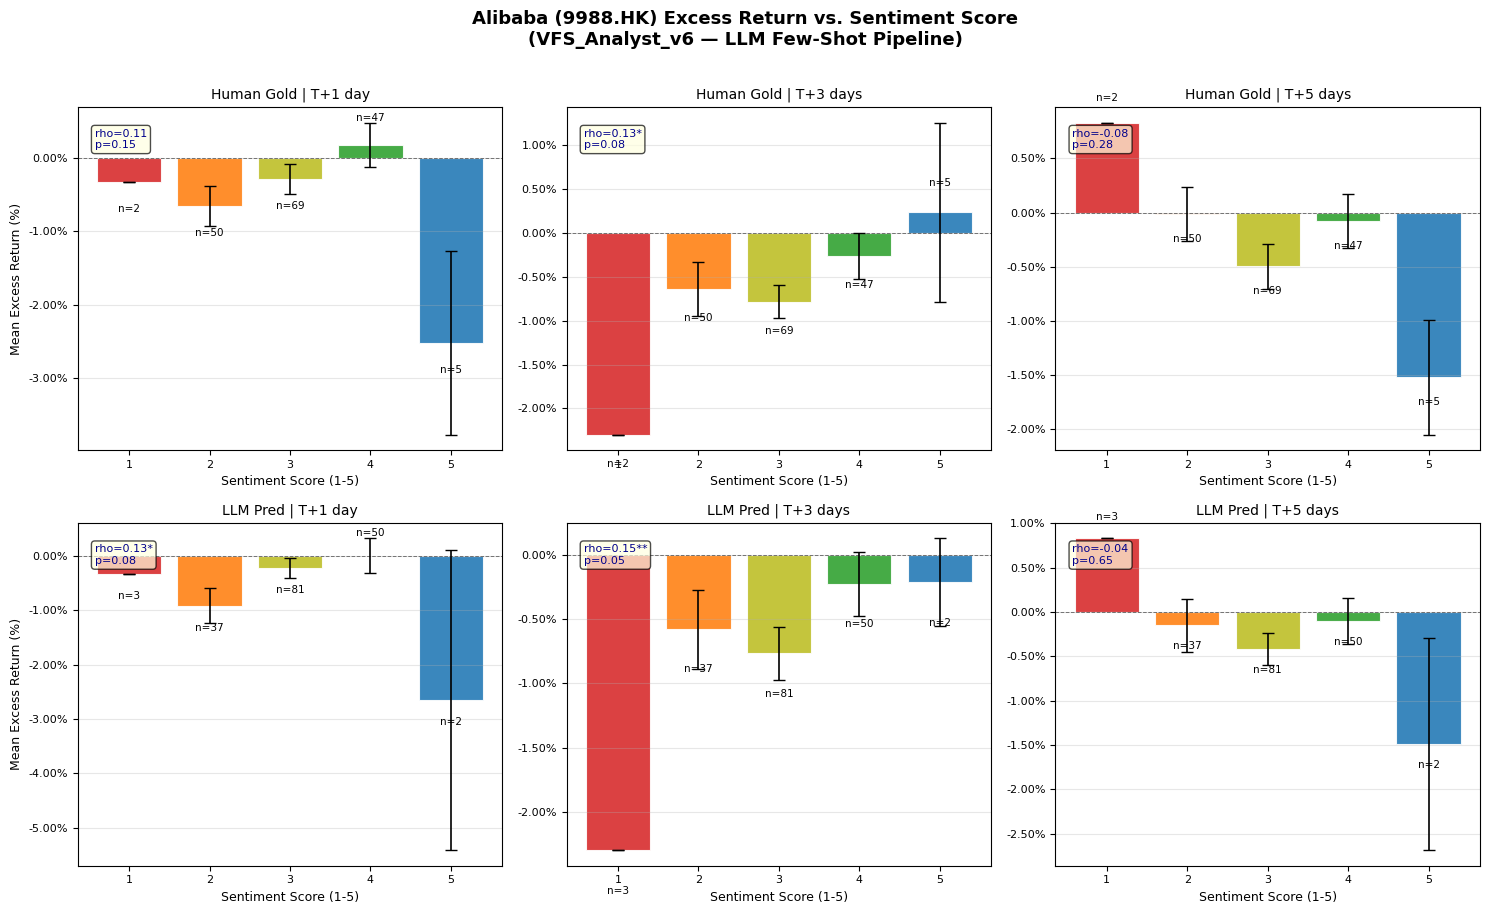

Figure saved: llm_sentiment_output\sentiment_vs_returns.png


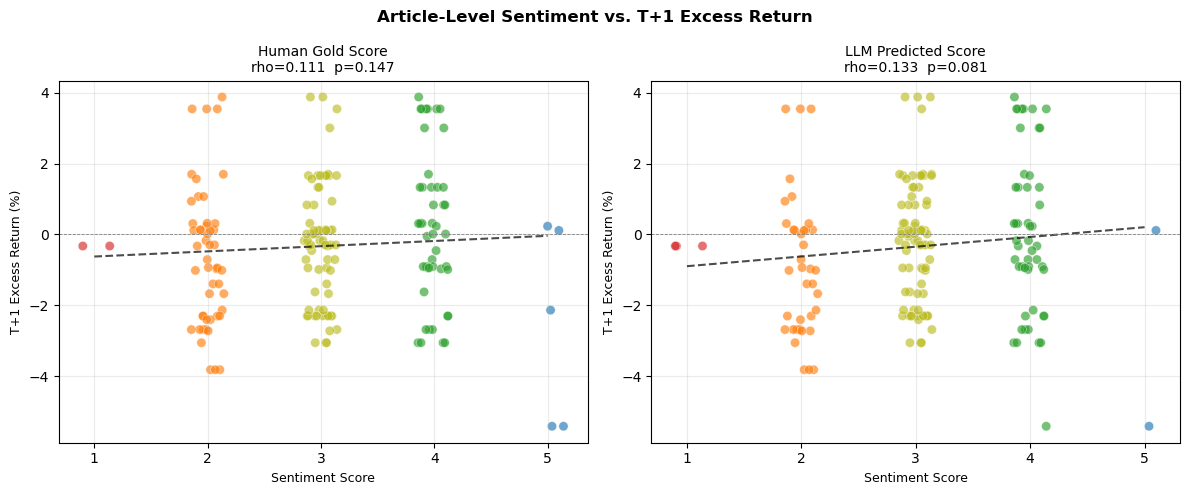

Scatter plot saved: llm_sentiment_output\sentiment_vs_returns_scatter.png


In [7]:
# ====================================================================
# Step 5c · Visualization — Sentiment Score vs. Excess Returns
# ====================================================================
# Generates two figures:
#   1. Bar chart: Mean excess return by sentiment score (2x3 grid)
#      - Rows: Human Gold Score vs. LLM Predicted Score
#      - Columns: T+1, T+3, T+5 horizons
#   2. Scatter plot: Article-level score vs. T+1 excess return
# ====================================================================

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

matplotlib.rcParams['font.family'] = 'DejaVu Sans'

df_plot = df_valid.dropna(subset=['excess_t1', 'excess_t3', 'excess_t5']).copy()
df_plot['gold'] = df_plot['gold'].astype(int)
df_plot['pred'] = df_plot['pred'].astype(int)

# ------------------------------------------------------------------
# Figure 1: Bar chart — Mean excess return by score bucket
# ------------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle("Alibaba (9988.HK) Excess Return vs. Sentiment Score\n(VFS_Analyst_v6 — LLM Few-Shot Pipeline)",
             fontsize=13, fontweight='bold', y=1.01)

COLORS = ['#d62728', '#ff7f0e', '#bcbd22', '#2ca02c', '#1f77b4']   # Score 1->5
HORIZONS = ['t1', 't3', 't5']
HORIZON_LABELS = ['T+1 day', 'T+3 days', 'T+5 days']

for col_idx, (hz, hz_label) in enumerate(zip(HORIZONS, HORIZON_LABELS)):
    ret_col = f'excess_{hz}'

    for row_idx, (score_col, title_prefix) in enumerate([('gold', 'Human Gold'), ('pred', 'LLM Pred')]):
        ax = axes[row_idx][col_idx]
        grp = df_plot.groupby(score_col)[ret_col].agg(['mean', 'count', 'std'])
        grp['se'] = grp['std'] / np.sqrt(grp['count'])

        bars = ax.bar(grp.index, grp['mean'] * 100,
                      color=[COLORS[s - 1] for s in grp.index],
                      edgecolor='white', linewidth=0.8, alpha=0.88)
        ax.errorbar(grp.index, grp['mean'] * 100,
                    yerr=grp['se'] * 100, fmt='none', color='black',
                    capsize=4, linewidth=1.2)
        ax.axhline(0, color='black', linewidth=0.7, linestyle='--', alpha=0.5)

        # Annotate sample size on each bar
        _y_range = max(abs(grp['mean'] * 100).max(), 0.05)
        _offset  = _y_range * 0.12
        for bar, (sc, row_g) in zip(bars, grp.iterrows()):
            h = bar.get_height()
            va = 'bottom' if row_g['mean'] >= 0 else 'top'
            y_pos = h + (_offset if row_g['mean'] >= 0 else -_offset)
            ax.text(bar.get_x() + bar.get_width() / 2, y_pos,
                    f"n={int(row_g['count'])}", ha='center', va=va, fontsize=7.5)

        ax.set_title(f"{title_prefix} | {hz_label}", fontsize=10)
        ax.set_xlabel("Sentiment Score (1-5)", fontsize=9)
        ax.set_ylabel("Mean Excess Return (%)" if col_idx == 0 else "", fontsize=9)
        ax.set_xticks([1, 2, 3, 4, 5])
        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f%%'))
        ax.tick_params(labelsize=8)
        ax.grid(axis='y', alpha=0.3)

        # Spearman rho annotation
        _d = df_plot[[score_col, ret_col]].dropna()
        _rho, _p = scipy_stats.spearmanr(_d[score_col].astype(float), _d[ret_col].astype(float))
        _sig = '**' if _p < 0.05 else ('*' if _p < 0.10 else '')
        ax.annotate(f"rho={_rho:.2f}{_sig}\np={_p:.2f}",
                    xy=(0.04, 0.88), xycoords='axes fraction',
                    fontsize=8, color='darkblue',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.7))

plt.tight_layout()
_fig_path = os.path.join(OUTPUT_DIR, "sentiment_vs_returns.png")
plt.savefig(_fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure saved: {_fig_path}")

# ------------------------------------------------------------------
# Figure 2: Scatter plot — article-level score vs T+1 excess return
# ------------------------------------------------------------------
fig2, axes2 = plt.subplots(1, 2, figsize=(12, 5))
fig2.suptitle("Article-Level Sentiment vs. T+1 Excess Return", fontsize=12, fontweight='bold')

for ax, (sc_col, label) in zip(axes2, [('gold', 'Human Gold Score'), ('pred', 'LLM Predicted Score')]):
    _d = df_plot[[sc_col, 'excess_t1']].dropna()
    jitter = np.random.default_rng(42).uniform(-0.15, 0.15, size=len(_d))
    ax.scatter(_d[sc_col] + jitter, _d['excess_t1'] * 100,
               c=[COLORS[s - 1] for s in _d[sc_col].astype(int)],
               alpha=0.65, s=45, edgecolors='white', linewidths=0.4)
    # Linear trend line
    _x = _d[sc_col].astype(float).values
    _y = _d['excess_t1'].values * 100
    _fit = np.polyfit(_x, _y, 1)
    _xx = np.linspace(1, 5, 50)
    ax.plot(_xx, np.polyval(_fit, _xx), color='black', linewidth=1.5, linestyle='--', alpha=0.7)

    _rho, _p = scipy_stats.spearmanr(_x, _y)
    ax.set_title(f"{label}\nrho={_rho:.3f}  p={_p:.3f}", fontsize=10)
    ax.set_xlabel("Sentiment Score", fontsize=9)
    ax.set_ylabel("T+1 Excess Return (%)", fontsize=9)
    ax.set_xticks([1, 2, 3, 4, 5])
    ax.axhline(0, color='grey', linewidth=0.6, linestyle='--')
    ax.grid(alpha=0.25)

plt.tight_layout()
_fig2_path = os.path.join(OUTPUT_DIR, "sentiment_vs_returns_scatter.png")
plt.savefig(_fig2_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Scatter plot saved: {_fig2_path}")